---
## 4. Exploratory Analysis

Each subsection below answers one of the four project research questions.

This notebook continues from `data_cleaning.ipynb`. It loads the cleaned FIRMS outputs from `data/processed/` and then answers the four project research questions with summary tables and figures.

In [2]:
# --- Standard library ---
from pathlib import Path
import warnings

# --- Data manipulation ---
import numpy as np
import pandas as pd

# --- Geospatial ---
import geopandas as gpd

# --- Visualisation ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

# Robust project-root detection:
# - if this notebook is run from notebooks/, project root is one level up
# - if it is run from the project root, project root is the current folder
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name.lower() in {"notebook", "notebooks"} else cwd

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Must match the output created in data_cleaning.ipynb
CLEAN_CSV = PROCESSED_DATA_DIR / "firms_viirs_cleaned.csv"
CLEAN_GPKG = PROCESSED_DATA_DIR / "firms_viirs_cleaned.gpkg"

# The retrieval notebook currently uses a 5-day global FIRMS request.
# Change this value if you change DAYS in data_retrieval.ipynb.
DAYS = 5

print(f"Project root       : {PROJECT_ROOT}")
print(f"Processed data dir : {PROCESSED_DATA_DIR}")
print(f"Figure output dir  : {OUTPUT_DIR}")


Project root       : /Users/davidleu/Desktop/sds210-wildfire-mapping-project
Processed data dir : /Users/davidleu/Desktop/sds210-wildfire-mapping-project/data/processed
Figure output dir  : /Users/davidleu/Desktop/sds210-wildfire-mapping-project/outputs/figures


### 4.0 Load cleaned FIRMS data

The previous notebook exports both a cleaned CSV and a GeoPackage. The GeoPackage is preferred because it already contains point geometry. If it is not available, the notebook falls back to the cleaned CSV and rebuilds the geometry from longitude and latitude.


In [3]:
def load_cleaned_firms_data(clean_gpkg: Path, clean_csv: Path) -> gpd.GeoDataFrame:
    """
    Load cleaned FIRMS fire detections produced by data_cleaning.ipynb.

    Preferred input
    ---------------
    data/processed/firms_viirs_cleaned.gpkg, layer='fires'

    Fallback input
    --------------
    data/processed/firms_viirs_cleaned.csv, with longitude/latitude columns
    """
    if clean_gpkg.exists():
        gdf = gpd.read_file(clean_gpkg, layer="fires")
        source = clean_gpkg
    elif clean_csv.exists():
        df = pd.read_csv(clean_csv, parse_dates=["acq_datetime"])
        geometry = gpd.points_from_xy(df["longitude"], df["latitude"])
        gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")
        source = clean_csv
    else:
        raise FileNotFoundError(
            "No cleaned FIRMS output was found. Run data_cleaning.ipynb first.\n"
            f"Expected one of:\n- {clean_gpkg}\n- {clean_csv}"
        )

    # Ensure the datetime column is parsed correctly even when loaded from GeoPackage
    if "acq_datetime" in gdf.columns:
        gdf["acq_datetime"] = pd.to_datetime(gdf["acq_datetime"], errors="coerce", utc=True)

    required_cols = {"latitude", "longitude", "frp", "confidence", "continent", "daynight", "geometry"}
    missing_cols = required_cols.difference(gdf.columns)
    if missing_cols:
        raise KeyError(f"Cleaned data is missing required columns: {sorted(missing_cols)}")

    return gdf, source


fires_gdf, data_source = load_cleaned_firms_data(CLEAN_GPKG, CLEAN_CSV)

print(f"Loaded cleaned FIRMS data from: {data_source}")
print(f"Rows: {len(fires_gdf):,} | Columns: {fires_gdf.shape[1]} | CRS: {fires_gdf.crs}")
print(f"Date range: {fires_gdf['acq_datetime'].min()} → {fires_gdf['acq_datetime'].max()}")
fires_gdf.head(3)


Loaded cleaned FIRMS data from: /Users/davidleu/Desktop/sds210-wildfire-mapping-project/data/processed/firms_viirs_cleaned.gpkg
Rows: 133,061 | Columns: 18 | CRS: EPSG:4326
Date range: 2026-05-07 00:01:00+00:00 → 2026-05-11 16:35:00+00:00


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,acq_datetime,continent,frp_normalised,geometry
0,-10.38626,34.97153,311.74,0.78,0.78,2026-05-07,0001,N,VIIRS,n,2.0NRT,285.90,2.92,N,2026-05-07 00:01:00+00:00,Africa,0.004909,POINT (34.97153 -10.38626)
1,-8.20365,32.76895,302.43,0.52,0.67,2026-05-07,0001,N,VIIRS,n,2.0NRT,288.00,0.88,N,2026-05-07 00:01:00+00:00,Africa,0.001479,POINT (32.76895 -8.20365)
2,-6.85891,12.39353,319.00,0.37,0.58,2026-05-07,0001,N,VIIRS,n,2.0NRT,287.29,8.19,N,2026-05-07 00:01:00+00:00,Africa,0.013768,POINT (12.39353 -6.85891)


### Q1 — Where are the most severe active wildfires?

**Fire Radiative Power (FRP)** in megawatts (MW) is the primary measure of fire intensity. Higher FRP indicates a hotter, more energetic fire that is consuming fuel at a faster rate. We identify the top-10 detections globally.

In [4]:
def get_top_fires(gdf: gpd.GeoDataFrame, top_n: int = 10) -> gpd.GeoDataFrame:
    """
    Return the top_n fire detections ranked by descending Fire Radiative Power.

    Parameters
    ----------
    gdf   : Cleaned GeoDataFrame of fire detections.
    top_n : Number of top records to return (default 10).

    Returns
    -------
    gpd.GeoDataFrame sorted by frp descending.
    """
    return gdf.nlargest(top_n, "frp")[["latitude", "longitude", "frp",
                                        "confidence", "continent",
                                        "acq_datetime", "daynight"]]


top_fires_gdf = get_top_fires(fires_gdf, top_n=10)

print("Top 10 fire detections by Fire Radiative Power (MW):")
top_fires_gdf.reset_index(drop=True).to_string(index=True)

Top 10 fire detections by Fire Radiative Power (MW):


'   latitude  longitude     frp confidence continent              acq_datetime daynight\n0  48.71250  133.41542  594.87          n      Asia 2026-05-11 03:10:00+00:00        D\n1  50.71302  129.94215  547.92          h      Asia 2026-05-11 04:55:00+00:00        D\n2  50.71795  129.90306  508.21          l      Asia 2026-05-11 04:55:00+00:00        D\n3  10.46708  -14.06049  480.34          l    Africa 2026-05-11 14:52:00+00:00        D\n4  10.46773  -14.05548  480.34          h    Africa 2026-05-11 14:52:00+00:00        D\n5  10.47172  -14.06126  480.34          l    Africa 2026-05-11 14:52:00+00:00        D\n6  10.47239  -14.05617  480.34          n    Africa 2026-05-11 14:52:00+00:00        D\n7 -22.05643  123.12157  463.07          l   Oceania 2026-05-07 05:50:00+00:00        D\n8 -22.05277  123.12083  463.07          n   Oceania 2026-05-07 05:50:00+00:00        D\n9  50.73161  129.97719  438.94          l      Asia 2026-05-11 04:55:00+00:00        D'

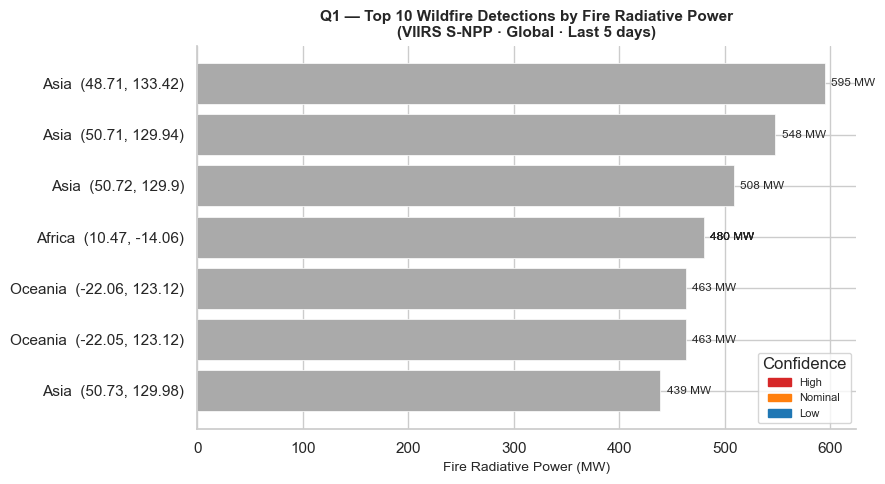

Figure saved to outputs/figures/q1_top_fires_frp.png


In [5]:
# ── Q1 visualisation: horizontal bar chart of top-10 fires ────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

top_fires_reset = top_fires_gdf.reset_index(drop=True)

# Create a label combining continent + short coordinates
top_fires_reset["label"] = (
    top_fires_reset["continent"]
    + "  ("
    + top_fires_reset["latitude"].round(2).astype(str)
    + ", "
    + top_fires_reset["longitude"].round(2).astype(str)
    + ")"
)

# Colour bars by confidence level
confidence_colours = {"high": "#d62728", "nominal": "#ff7f0e", "low": "#1f77b4"}
bar_colours = top_fires_reset["confidence"].map(confidence_colours).fillna("#aaaaaa")

bars = ax.barh(
    top_fires_reset["label"],
    top_fires_reset["frp"],
    color=bar_colours,
    edgecolor="white",
    linewidth=0.5,
)

# Annotate bar ends with FRP values
for bar, frp_val in zip(bars, top_fires_reset["frp"]):
    ax.text(
        bar.get_width() + top_fires_reset["frp"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{frp_val:,.0f} MW",
        va="center",
        fontsize=8.5,
    )

# Legend for confidence colours
legend_patches = [
    mpatches.Patch(color=col, label=lbl.capitalize())
    for lbl, col in confidence_colours.items()
]
ax.legend(handles=legend_patches, title="Confidence", loc="lower right", fontsize=8)

ax.invert_yaxis()
ax.set_xlabel("Fire Radiative Power (MW)", fontsize=10)
ax.set_title(
    "Q1 — Top 10 Wildfire Detections by Fire Radiative Power\n"
    f"(VIIRS S-NPP · Global · Last {DAYS} days)",
    fontsize=11,
    fontweight="bold",
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "q1_top_fires_frp.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to outputs/figures/q1_top_fires_frp.png")

**Interpretation:** The horizontal bars reveal which geographic regions are currently hosting the most energetically intense fires. Bar colour encodes detection confidence: red bars (high confidence) are the most reliable detections, orange bars (nominal) are probable fires, and blue bars (low confidence) should be interpreted with caution.

---
### Q2 — How does thermal intensity (FRP) vary across continents?

We compare the distribution of FRP across continents using box plots and summary statistics. This reveals whether certain regions consistently host more intense fire events.

In [6]:
def summarise_frp_by_continent(gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    Compute descriptive FRP statistics grouped by continent.

    Parameters
    ----------
    gdf : Cleaned GeoDataFrame with 'frp' and 'continent' columns.

    Returns
    -------
    pd.DataFrame with count, median, mean, 90th-percentile, and max FRP per continent.
    """
    summary = (
        gdf.groupby("continent")["frp"]
        .agg(
            count="count",
            median="median",
            mean="mean",
            p90=lambda x: x.quantile(0.90),
            max_frp="max",
        )
        .round(1)
        .sort_values("median", ascending=False)
    )
    summary.columns = ["Count", "Median FRP (MW)", "Mean FRP (MW)",
                       "90th-Pct FRP (MW)", "Max FRP (MW)"]
    return summary


frp_continent_summary = summarise_frp_by_continent(fires_gdf)
print("FRP summary statistics by continent:")
frp_continent_summary

FRP summary statistics by continent:


,Count,Median FRP (MW),Mean FRP (MW),90th-Pct FRP (MW),Max FRP (MW)
continent,,,,,
Africa,35861,5.0,9.2,17.5,480.3
Oceania,16857,4.6,8.2,15.7,463.1
South America,8122,4.5,7.3,14.8,209.9
North America,19506,4.3,7.6,15.0,355.0
Asia,47538,4.0,7.1,13.2,594.9
Other,467,3.2,4.5,9.5,31.4
Europe,4710,3.0,6.5,12.7,390.3


/var/folders/zb/zbgtld8568gbpf4x8l62p6bm0000gn/T/ipykernel_49851/1006493652.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


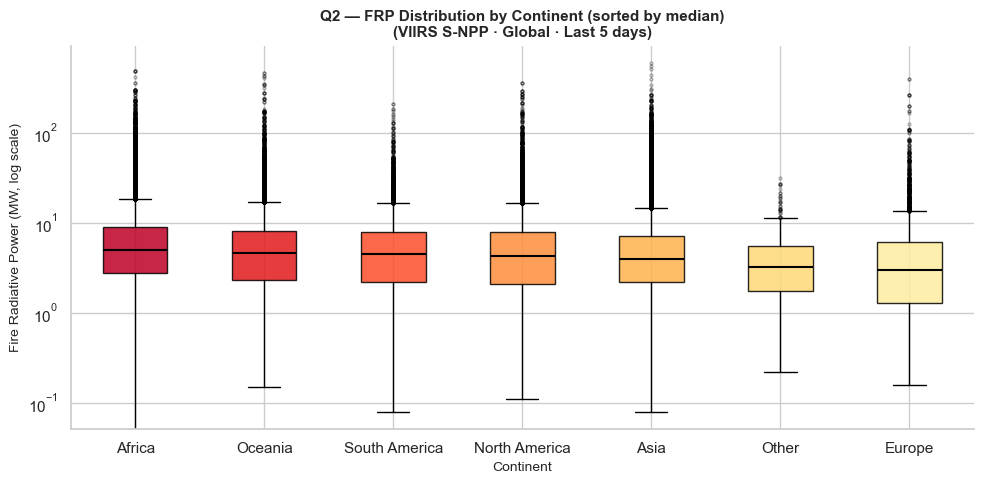

Figure saved to outputs/figures/q2_frp_by_continent.png


In [7]:
# ── Q2 visualisation: box plots of FRP by continent (log scale) ───────────────
continent_order = frp_continent_summary.index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))

continent_groups = [
    fires_gdf.loc[fires_gdf["continent"] == cont, "frp"].dropna().values
    for cont in continent_order
]

bp = ax.boxplot(
    continent_groups,
    labels=continent_order,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
    flierprops=dict(marker="o", markersize=2, alpha=0.3, color="#888"),
    showfliers=True,
)

# Apply a colour gradient from dark orange to light blue
box_colours = sns.color_palette("YlOrRd_r", len(continent_order))
for patch, colour in zip(bp["boxes"], box_colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.85)

ax.set_yscale("log")
ax.set_ylabel("Fire Radiative Power (MW, log scale)", fontsize=10)
ax.set_xlabel("Continent", fontsize=10)
ax.set_title(
    "Q2 — FRP Distribution by Continent (sorted by median)\n"
    f"(VIIRS S-NPP · Global · Last {DAYS} days)",
    fontsize=11,
    fontweight="bold",
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "q2_frp_by_continent.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to outputs/figures/q2_frp_by_continent.png")

**Interpretation:** The logarithmic scale accommodates the heavy right-skew of FRP distributions — a handful of extreme fire events dominate the raw values. Continents sorted left-to-right by median FRP reveal systematic differences: regions with tropical forest fires and savanna burning typically show higher median intensities, while Mediterranean and boreal fire regimes often appear more variable. Long whiskers and numerous outliers highlight that peak intensities can be orders of magnitude above the typical event.

---
### Q3 — Are fires detected more often during day or night passes, and does this vary by region?

The VIIRS sensor records a `daynight` flag (`D` = daytime overpass, `N` = nighttime). Because the satellite orbit controls detection opportunity, understanding this split helps contextualize detection counts.

In [8]:
def compute_daynight_breakdown(gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    Summarise the proportion of day vs. night fire detections by continent.

    Parameters
    ----------
    gdf : GeoDataFrame with 'daynight' and 'continent' columns.

    Returns
    -------
    pd.DataFrame with columns ['D', 'N'] (counts) and a 'Day %' column.
    """
    if "daynight" not in gdf.columns:
        raise KeyError("'daynight' column not found in dataset.")

    pivot = (
        gdf.groupby(["continent", "daynight"])
        .size()
        .unstack(fill_value=0)
    )

    # Ensure both columns exist even if one category is absent
    for flag in ["D", "N"]:
        if flag not in pivot.columns:
            pivot[flag] = 0

    pivot["Total"]  = pivot["D"] + pivot["N"]
    pivot["Day %"]  = (pivot["D"] / pivot["Total"] * 100).round(1)
    pivot["Night %"] = (pivot["N"] / pivot["Total"] * 100).round(1)

    return pivot[["D", "N", "Total", "Day %", "Night %"]].sort_values("Total", ascending=False)


daynight_table = compute_daynight_breakdown(fires_gdf)
print("Day vs. Night detection breakdown by continent:")
daynight_table

Day vs. Night detection breakdown by continent:


daynight,D,N,Total,Day %,Night %
continent,,,,,
Asia,35999,11539,47538,75.7,24.3
Africa,28697,7164,35861,80.0,20.0
North America,12989,6517,19506,66.6,33.4
Oceania,11998,4859,16857,71.2,28.8
South America,5304,2818,8122,65.3,34.7
Europe,2459,2251,4710,52.2,47.8
Other,274,193,467,58.7,41.3


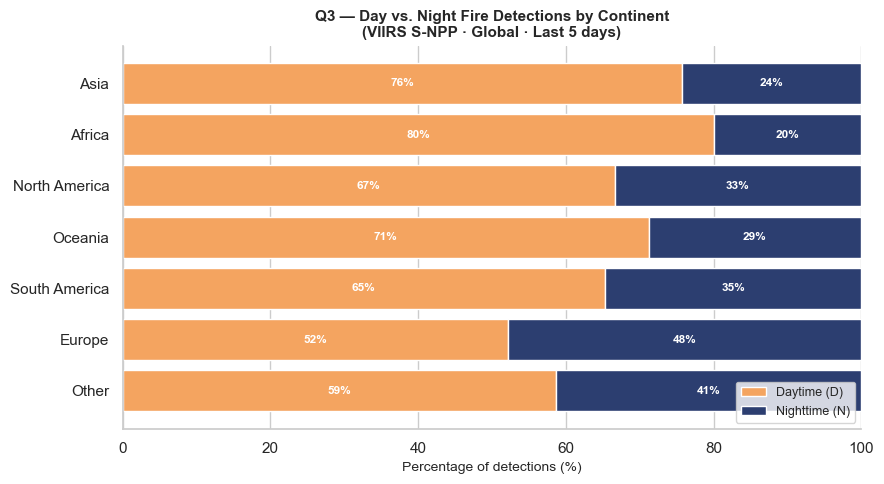

Figure saved to outputs/figures/q3_daynight_by_continent.png


In [9]:
# ── Q3 visualisation: stacked bar chart (100 % normalised) ────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

day_pct   = daynight_table["Day %"].values
night_pct = daynight_table["Night %"].values
continents = daynight_table.index.tolist()

ax.barh(continents, day_pct,   color="#f4a460", label="Daytime (D)",  edgecolor="white")
ax.barh(continents, night_pct, color="#2c3e70", label="Nighttime (N)",
        left=day_pct, edgecolor="white")

# Add percentage labels inside bars
for i, (d, n) in enumerate(zip(day_pct, night_pct)):
    if d > 8:
        ax.text(d / 2,       i, f"{d:.0f}%",  ha="center", va="center",
                fontsize=8.5, color="white", fontweight="bold")
    if n > 8:
        ax.text(d + n / 2,   i, f"{n:.0f}%",  ha="center", va="center",
                fontsize=8.5, color="white", fontweight="bold")

ax.set_xlim(0, 100)
ax.set_xlabel("Percentage of detections (%)", fontsize=10)
ax.set_title(
    "Q3 — Day vs. Night Fire Detections by Continent\n"
    f"(VIIRS S-NPP · Global · Last {DAYS} days)",
    fontsize=11,
    fontweight="bold",
)
ax.legend(loc="lower right", fontsize=9)
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "q3_daynight_by_continent.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to outputs/figures/q3_daynight_by_continent.png")

**Interpretation:** VIIRS completes roughly 14 orbits per day and crosses each latitude twice (ascending night and descending day pass). A 50/50 split at the global level reflects the sensor design. Systematic departures from 50 % in individual regions indicate geographic or orbital effects — for instance, at very high latitudes the sun may be above the horizon even during the satellite's nominal 'night' pass, inflating daytime detection counts.

---
### Q4 — How does detection confidence relate to fire intensity (FRP)?

VIIRS assigns each detection a confidence class: **low**, **nominal**, or **high**. We test whether higher confidence genuinely corresponds to higher FRP — if it does, confidence is a valid proxy for fire severity in the absence of FRP data.

In [10]:
def summarise_frp_by_confidence(gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    Compute FRP statistics grouped by confidence class.

    VIIRS FIRMS encodes confidence as single letters (l, n, h). This function
    maps them to readable labels (low, nominal, high) before aggregating.

    Parameters
    ----------
    gdf : GeoDataFrame with 'frp' and 'confidence' columns.

    Returns
    -------
    pd.DataFrame with count, mean, median, and max FRP per confidence class.
    """
    confidence_label_map = {"l": "low", "n": "nominal", "h": "high"}
    canonical_order = ["low", "nominal", "high"]

    df = gdf[["frp", "confidence"]].copy()
    df["confidence"] = df["confidence"].map(confidence_label_map)
    df = df.dropna(subset=["confidence", "frp"])

    present_classes = [c for c in canonical_order if c in df["confidence"].unique()]

    summary = (
        df[df["confidence"].isin(present_classes)]
        .groupby("confidence", observed=True)["frp"]
        .agg(
            count="count",
            mean="mean",
            median="median",
            max_frp="max",
        )
        .round(1)
        .reindex(present_classes)
    )
    summary.columns = ["Count", "Mean FRP (MW)", "Median FRP (MW)", "Max FRP (MW)"]
    return summary


frp_confidence_summary = summarise_frp_by_confidence(fires_gdf)
print("FRP statistics by confidence class:")
frp_confidence_summary

FRP statistics by confidence class:


,Count,Mean FRP (MW),Median FRP (MW),Max FRP (MW)
confidence,,,,
low,14559,9.8,4.4,508.2
nominal,112627,6.8,4.1,594.9
high,5875,22.5,13.3,547.9


/var/folders/zb/zbgtld8568gbpf4x8l62p6bm0000gn/T/ipykernel_49851/1469916264.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.capitalize() for c in confidence_order])


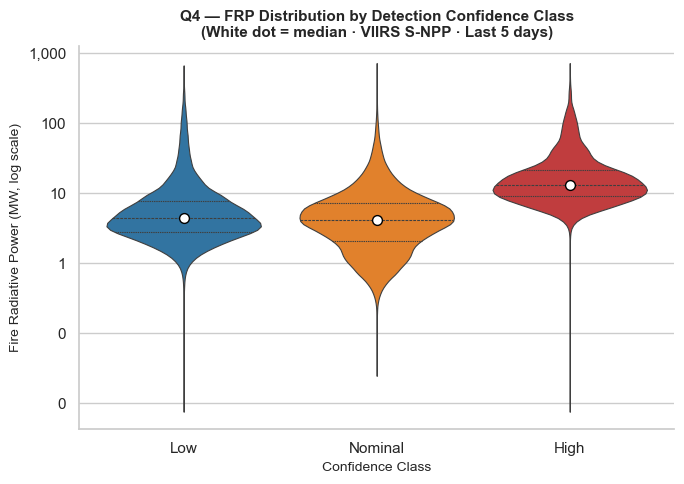

Figure saved to outputs/figures/q4_frp_by_confidence.png


In [11]:
# ── Q4 visualisation: violin plot (FRP by confidence) ────────────────────────
# VIIRS FIRMS encodes confidence as single letters: l = low, n = nominal, h = high.
# Map to readable labels so plotting and downstream filtering work.
confidence_label_map = {"l": "low", "n": "nominal", "h": "high"}
canonical_order = ["low", "nominal", "high"]
confidence_colours = {"low": "#1f77b4", "nominal": "#ff7f0e", "high": "#d62728"}

plot_data = fires_gdf[["frp", "confidence"]].copy()
plot_data["confidence"] = plot_data["confidence"].map(confidence_label_map)
plot_data = plot_data.dropna(subset=["confidence", "frp"])

# Preserve canonical order, but only keep classes actually present in the data
confidence_order = [c for c in canonical_order if c in plot_data["confidence"].unique()]

if plot_data.empty or not confidence_order:
    raise ValueError("No valid confidence classes found for Q4 visualisation.")

# Log-transform FRP to compress the heavy tail
plot_data["log_frp"] = np.log10(plot_data["frp"].clip(lower=0.01))

fig, ax = plt.subplots(figsize=(7, 5))

sns.violinplot(
    data=plot_data,
    x="confidence",
    y="log_frp",
    order=confidence_order,
    palette={k: confidence_colours[k] for k in confidence_order},
    inner="quartile",
    linewidth=0.8,
    ax=ax,
)

# Overlay median markers
for i, conf in enumerate(confidence_order):
    median_log = plot_data.loc[plot_data["confidence"] == conf, "log_frp"].median()
    ax.scatter(i, median_log, color="white", s=50, zorder=5, edgecolors="black", linewidths=1)

# Re-label y-axis ticks as actual MW values
valid_min = np.floor(plot_data["log_frp"].min())
valid_max = np.ceil(plot_data["log_frp"].max())
y_ticks = np.arange(valid_min, valid_max + 1)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{10**v:,.0f}" for v in y_ticks])

ax.set_xlabel("Confidence Class", fontsize=10)
ax.set_ylabel("Fire Radiative Power (MW, log scale)", fontsize=10)
ax.set_xticklabels([c.capitalize() for c in confidence_order])
ax.set_title(
    "Q4 — FRP Distribution by Detection Confidence Class\n"
    f"(White dot = median · VIIRS S-NPP · Last {DAYS} days)",
    fontsize=11,
    fontweight="bold",
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "q4_frp_by_confidence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to outputs/figures/q4_frp_by_confidence.png")

**Interpretation:** If confidence is a meaningful quality indicator, we expect median FRP to increase from low → nominal → high. A statistically significant monotonic increase validates using confidence as a visual symbolization variable on the map. Conversely, if the distributions overlap substantially, FRP itself should be the primary encoding variable.